# Template matching notebook - an example
This notebook demonstrates templatematching of Scanning Precession Electron Diffraction (SPED) datasets for orientationmapping of crystalline materials using the `pyxem` package. It demonstrates this by showing it on a pre-processed SPED dataset acquired on the GrandARM TEM in Trondheim. The data has been preprocessed using the `4D_STEM_preprocessing.ipynb`.

A composite overlaid image of several virtual dark field (VDF) images of the sample looks something like this:

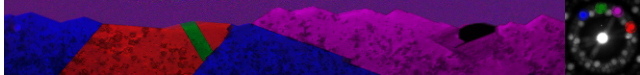

There are several twins in the dataset, which are given a distinct color in the image above. In this notebook we will apply template matching to find the orientations of these twins and demonstrate the method and how to visualize the results

## Contents
 1. [Loading the data](#1.-Load-and-inspect-the-data)
 2. [Create library of simulated diffraction patterns](#2.-Create-library-of-simulated-diffraction-patterns)
 3. [Template match a subset](#3.-Template-match-(a-subset))
 4. [Template match the entire dataset](#4.-Template-match-the-entire-dataset)
 5. [Create a crystal map](#5.-Create-a-crystal-map)
 6. [Correcting for the scan rotation](#6.-Correcting-for-the-scan-rotation)

 ## Requrirements
 - pyxem 0.21.0

## Credits
 - This notebook was created for pyxem 0.15 by [Emil Frang Christiansen](https://www.ntnu.edu/employees/emil.christiansen) - [emil.christiansen@ntnu.no](emil.christiansen@ntnu.no)
 - This notebook was updated to pyxem 0.19.1 based on the notebook by [Tina Bergh](https://www.ntnu.edu/employees/tina.bergh) for the [NordTEMHub 4DSTEM workshop Summer 2024](https://github.com/TEM-Gemini-Centre/nordtemhub_4DSTEMworkshop_2024/blob/main/Orientation_mapping_SPED-Ag/Orientation_mapping_SPED-Ag.ipynb)
 - Now: pyxem 0.21.0. 

## Some useful resources/references
 - [`Orix` IPF reference](https://orix.readthedocs.io/en/stable/tutorials/inverse_pole_figures.html)
 - [`Orix`Crystal map documentation](https://orix.readthedocs.io/en/stable/tutorials/crystal_map.html)
 - [`Pyxem` template matching demo notebook](https://github.com/pyxem/pyxem-demos/blob/master/11%20Accelerated%20orientation%20mapping%20with%20template%20matching.ipynb)

In [1]:
%matplotlib widget

#Pyxem tends to give alot of warnings. We choose to ignore most of them in this notebook. However this is NOT recommended for your own work, as some warnings might give very useful information!
import warnings
warnings.filterwarnings('ignore')

import hyperspy.api as hs #General hyperspy package
import pyxem as pxm #Electron diffraction tools based on hyperspy
import numpy as np #General numerical and matrix support
import matplotlib.pyplot as plt #Plotting tools
import matplotlib.colors as mcolors #Some plotting color tools
from matplotlib.cm import ScalarMappable
import diffpy #Electron diffraction tools
import requests

import hyperspy_gui_ipywidgets
import hyperspy.ui_registry as ur

import pandas as pd
import seaborn as sb
from tabulate import tabulate

#Import path handling tool
from pathlib import Path

#Import indexation and plotting tools
from diffsims.generators.rotation_list_generators import get_beam_directions_grid
from diffsims.libraries.structure_library import StructureLibrary
from diffsims.generators.diffraction_generator import DiffractionGenerator
from diffsims.generators.library_generator import DiffractionLibraryGenerator
from diffsims.generators.simulation_generator import SimulationGenerator

#Import orientation handling tools
from orix.quaternion import Rotation, symmetry, Orientation
from orix.crystal_map import Phase
from orix.vector.vector3d import Vector3d
from orix.vector import Miller
from orix.projections import StereographicProjection
from orix import plot
from orix.plot import IPFColorKeyTSL
from orix.sampling import get_sample_reduced_fundamental
from orix.io import save, load

# 1. Load and inspect the data

Load the preprocessed data. It should already be well calibrated and centered. When analysing your own data you will need to perform the following steps:
1. Center all the diffraction patterns
2. Calibrate the diffraction scale
3. Measure or verify scan-diffraction rotation

_Tip: using the `pathlib.Path` object helps alot when dealing with data paths on multiple systems (e.g. windows and Unix) and when modifying paths for saving data_ 

In [2]:
#base_directory = Path("/Users/ingridmzg/Masteroppgave/Bilder/GrandARM/transfer_437760_files_bc69ddf3/")
base_directory = Path("GARM/437760")
files = list(base_directory.glob("*.hspy"))
print("Found files:")
for i, f in enumerate(files):
    print(f'{i}:/t{f}')

Found files:
0:/tGARM/437760/0003_4D-STEM_Single_pnADF.hspy
1:/tGARM/437760/0003_4D-STEM_Single_Image_cropped.hspy


In [3]:
# Select indices from the printed list
signal_idx = 1
navigator_idx = 0

signal_path = files[signal_idx]
navigator_path = files[navigator_idx]

In [4]:
# load lazy

lazy = True
signal = hs.load(str(signal_path), lazy=lazy) #Load the data. Use `lazy=True` if you are experiencing memory issues
if lazy:
    signal.rechunk(nav_chunks=(32, 32),sig_chunks=(32, 32))

pnADF = hs.load(str(navigator_path), lazy=True)

In [5]:
signal.set_signal_type("electron_diffraction") 

In [6]:
#datapath = Path("/Users/ingridmzg/Masteroppgave/Bilder/GrandARM/transfer_437934_files_e5e30d0b/0001_4D-STEM_Single_Image_ELA_SED128x128.hspy")

In [7]:
#lazy = True
#signal = hs.load(str(datapath), lazy=lazy) #Load the data. Use `lazy=True` if you are experiencing memory issues
#if lazy:
   # signal.rechunk(nav_chunks=(32, 32),sig_chunks=(32, 32))

In [8]:
signal

<LazyElectronDiffraction2D, title: 4D-STEM_Single_Image, dimensions: (128, 32|512, 512)>

Plot an interactive VBF/VDF to inspect the data if you wish.

In [9]:
signal.set_signal_type('electron_diffraction')

In [10]:
signal.plot(norm='symlog')

  0%|          | 0/4169 [00:00<?, ?it/s]

  0%|          | 0/4190 [00:00<?, ?it/s]

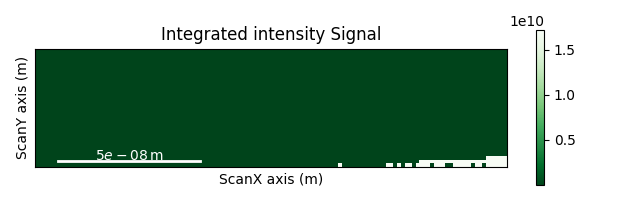

In [11]:
signal.plot_integrated_intensity(hs.roi.CircleROI(0.0, 0.0, 0.1), cmap='Greens_r')

In [12]:
assert False

AssertionError: 

In [13]:
print(f'The signal:\n{signal}\n') #Print information about the signal
print(f'Axes information:\n{signal.axes_manager}\n') #Print information about the axes
print(f'Data:\n{signal.data}\n')

The signal:
<LazyElectronDiffraction2D, title: 4D-STEM_Single_Image, dimensions: (128, 32|512, 512)>

Axes information:
<Axes manager, axes: (128, 32|512, 512)>
            Name |   size |  index |  offset |   scale |  units 
================ | ====== | ====== | ======= | ======= | ====== 
           ScanX |    128 |     25 | 7.2e-08 | 1.3e-09 |      m 
           ScanY |     32 |     12 | 2.5e-08 | 1.3e-09 |      m 
---------------- | ------ | ------ | ------- | ------- | ------ 
         CameraX |    512 |      0 |  -0.066 | 0.00026 |    rad 
         CameraY |    512 |      0 |  -0.066 | 0.00026 |    rad 

Data:
dask.array<rechunk-merge, shape=(32, 128, 512, 512), dtype=uint32, chunksize=(32, 32, 32, 32), chunktype=numpy.ndarray>



In [14]:
signal.axes_manager.gui()

In [15]:
assert False

AssertionError: 

In [16]:
print(f'Axes information:\n{signal.axes_manager}\n') #Print information about the axes

Axes information:
<Axes manager, axes: (128, 32|512, 512)>
            Name |   size |  index |  offset |   scale |  units 
================ | ====== | ====== | ======= | ======= | ====== 
           ScanX |    128 |     25 | 7.2e-08 |     1.3 |     nm 
           ScanY |     32 |     12 | 2.5e-08 |     1.3 |     nm 
---------------- | ------ | ------ | ------- | ------- | ------ 
         CameraX |    512 |      0 |  -0.066 | 0.00026 |    rad 
         CameraY |    512 |      0 |  -0.066 | 0.00026 |    rad 



# 2. Create library of simulated diffraction patterns
Next we need to create a library of diffraction patterns. This requires both a crystal structure and some simulation parameters. The crystal structure can be created "manually", but it is also convenient to use already made .cif files to define these. In this case, we download a .cif file for the silver FCC crystal structure from a repository at Springer: [https://materials.springer.com/downloads/track-required/true?path=%2Fassets%2Fsm_isp%2Fcrystallographic%2F914%2Fsm_isp_sd_1822504%2Fsm_isp_sd_1822504_download.cif&componentId=Download+Data+CIF](https://materials.springer.com/downloads/track-required/true?path=%2Fassets%2Fsm_isp%2Fcrystallographic%2F914%2Fsm_isp_sd_1822504%2Fsm_isp_sd_1822504_download.cif&componentId=Download+Data+CIF). 

__NB! You must be on NTNU VPN to get access to the cif-file!__

In [17]:
fname = 'GaAs.cif'
url = "https://materials.springer.com/downloads/track-required/true?path=%2Fassets%2Fsm_isp%2Fcrystallographic%2F311%2Fsm_isp_sd_0311662%2Fsm_isp_sd_0311662_download.cif&componentId=Download+Data+CIF"
r = requests.get(url)
open(fname , 'wb').write(r.content)

#GaAs = Phase.from_cif(fname)

3852

In [18]:
GaAs = Phase.from_cif("GaAs.cif")

### Create the simulations
Next, we need to define the beam directions we want to simulate diffraction patterns for. In the next cell, we first use the `orix.sampling.get_sample_reduced_fundamental()` function to create an array of Euler angles (rotations) that define the different beam directions we will simulate. These are then converted into the crystal reference frame by transofming them into directions (an `Orientation`) in the crystam. Then we visualize these orientations before creating the simulations.

The Euler angles define how to rotate a crystal unit cell with respect to a specimen/lab reference frame by three different angles. You can learn more about Euler angles in most crystallographic litterature or e.g. [https://en.wikipedia.org/wiki/Euler_angles](https://en.wikipedia.org/wiki/Euler_angles)

Simulated 8281 beam directions


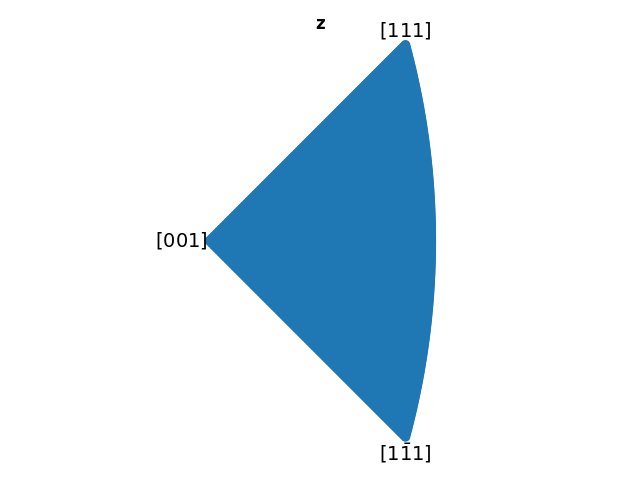

In [19]:
resolution = 0.5 #0.5. The angular spacing between each orientation

beam_directions = get_sample_reduced_fundamental(resolution, point_group=GaAs.point_group) #Get a uniform sampling of euler angles
print(f'Simulated {beam_directions.size} beam directions')
beam_orientations = Orientation(beam_directions, symmetry=GaAs.point_group)
beam_orientations.scatter('ipf')

In the figure above, you see the sampling we have done of the represented as points in an inverse pole figure (IPF). Since silver is cubic FCC, a very small part of the complete 3D rotation space is needed to describe any rotation of the crystal. Other crystal systems require larger parts of rotation space to be mapped (se e.g. [https://orix.readthedocs.io/en/stable/tutorials/inverse_pole_figures.html](https://orix.readthedocs.io/en/stable/tutorials/inverse_pole_figures.html) for more information). 

### Simulate diffraction patterns
The beam directions defined above only gives one half of what is needed to simulate diffraction patterns - the material and the directions. We also need to simulate our beam conditions and its interaction with this material. In the next cell, we create a `SimulationGenerator` that takes care of this interaction. To simulate the diffraction patterns based on the structures defined above, we alsoneed certain beam and interaction parameters. The following cell will use the calibration and shape of the signal you loaded earlier, so make sure that these are correct! In the next cell, it is also important to adjust the `minimum_intensity` and `max_excitation_error` parameters to suitable values. These parameters are related to extinct reflections and the excitation error and may vary depending on your material!

#### Extinct reflections
The `minimum_intensity` sets a lower threshold for the intensity accepted as a reflection. If this is set too low, you will get artefacts in your data - is is actually used to enforce the extinction rules of your structure! If you think about e.g. the FCC structure, reflections must have $(h, k, l)$ all even or all odd. Any mix of odd and even $(h, k, l)$ indices will give reflections of 0 intensity in a perfect crystal. However, these intensities will never actually be exactly zero, and the `minimum_intensity` parameter is used remove the extinct reflections.

#### Excitation error - "Sample thickness"
The `max_excitation_error` parameter sets the maximum distance from the reciprocal lattice point to the Ewald sphere that is allowed for a reflection. When simulating intensities of reflections, the reciprocal lattice points will have an assumed shape, and their "size" along the beam direction will be set by the `maximum_excitation_error`. From kinematical theory, the shape should follow a $sinc(\vec{k} \xi t)$ function as:

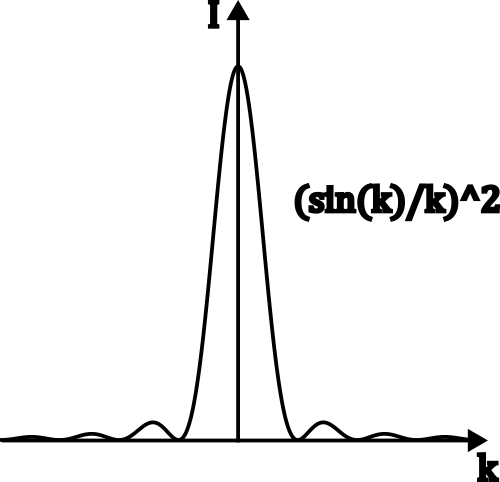

However, for template matching it is often enough to simulate them as a linear profile.




The other parameters might also be imporatant for your own work, for example you might need to apply some image intensity transformation functions (using `intensity_transform_function`) or reduce the part of reciprocal space that your are considering (using `max_r`).

In [20]:
minimum_intensity = 1E-10 #Tuneable parameter
max_excitation_error = 1E-1 #Tuneable parameter

sim_gen = SimulationGenerator(
    accelerating_voltage=signal.metadata.Acquisition_instrument.TEM.beam_energy,
    scattering_params='lobato',
    precession_angle=0,
    shape_factor_model='linear',
    approximate_precession=True,
    minimum_intensity=minimum_intensity
) #Create a diffraction simulation generator

calibration = signal.axes_manager[-1].scale #Get the calibration from the signal
reciprocal_radius = np.max(np.abs(signal.axes_manager[-1].axis)) #Get the maximum reciprocal radius to simulate
reciprocal_radius = np.ceil(reciprocal_radius) #Round up to the nearest integer for better performance
half_shape = np.min(signal.axes_manager.signal_shape)//2 #Get the half-shape of the patterns

print(f'I will simulate diffraction up to {reciprocal_radius}')



I will simulate diffraction up to 1.0


In [21]:
print(signal.axes_manager[-1].units)
print(signal.axes_manager[-1].scale)
print(signal.axes_manager[-1].axis[:5])
print(signal.metadata.Acquisition_instrument.TEM.beam_energy)


rad
0.0002568493150684931
[-0.06575342 -0.06549658 -0.06523973 -0.06498288 -0.06472603]
80.0


(<Axes: xlabel='$\\AA^{-1}$', ylabel='$\\AA^{-1}$'>,
 <matplotlib.collections.PathCollection at 0x7fded1f934c0>)

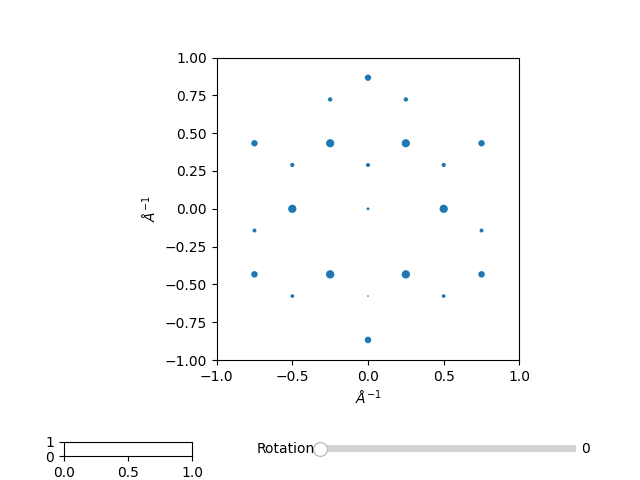

In [22]:
simulations = sim_gen.calculate_diffraction2d(
    phase=GaAs,
    rotation=beam_directions,
    reciprocal_radius=reciprocal_radius,
    with_direct_beam=False, #False
    max_excitation_error=max_excitation_error,
    shape_factor_width=None,
    debye_waller_factors=None    
)

simulations.plot(interactive=True)

In [35]:
subset.plot(norm='symlog')
roi = hs.roi.CircleROI(r=0.1)
roi.add_widget(subset, axes=(2,3))

In [36]:
roi

CircleROI(cx=-0.000513699, cy=-0.000513699, r=0.0597175, r_inner=0.00269692)

In [37]:
subset.axes_manager

Navigation axis name,size,index,offset,scale,units
ScanX,3,2,54.68750007161459,1.3020833333333335,nm
ScanY,3,1,29.947916691406256,1.3020833333333335,nm
Signal axis name,size,,offset,scale,units
CameraX,512,,-0.06575342465753424,0.0002568493150684931,rad
CameraY,512,,-0.06575342465753424,0.0002568493150684931,rad


In [39]:
cx, cy =roi.cx, roi.cy
(cx-subset.axes_manager[2].offset)/subset.axes_manager[2].scale, (cy-subset.axes_manager[3].offset)/subset.axes_manager[3].scale
ox, oy = (cx-subset.axes_manager[2].offset), (cy-subset.axes_manager[3].offset)
old_offsets = subset.axes_manager[2].offset, subset.axes_manager[3].offset
subset.axes_manager[2].offset = -ox
subset.axes_manager[3].offset = -oy


In [40]:
print(old_offsets)

(-0.06575342465753424, -0.06575342465753424)


In [ ]:
npt_azim = 360 #Number of azimuthal sampling points
subset.change_dtype('float32')
#subset.data = subset.data.astype(np.float32) # Added after "unsupported array-type appeared"
subset_pol = subset.get_azimuthal_integral2d(npt=npt, npt_azim=npt_azim)

# 3. Template match (a subset)

Templatematching is done on the data in polar coordinates, i.e. the data must be azimuthally integrated with `signal.get_azimuthal_intergral2d()` before templatematching (all orientation template matching routines are done in this space, even the other template matching tools of pyxem that works "directly" on the diffraction patterns). There are many important parameters you can set that determine how the azimuthal integration is performed. The most important ones are `npt`, and `npt_azim`. These determine the sampling in the radial and azimuthal directions, respectively. The default values of the remaining parameters are usually ok, but you should inspect how the integration looks afterwards!

As a first step, we work on a subset of our data. You can pick a specific pattern, or choose a random point in the scan and its closest surroundings. It is best to work on more than one scan point at a time, as this avoids certain errors in the code that is optimized to work on 2D maps. In the next cell, we pick a random pixel in the data, and then take a $3\times3$ area starting at that pixel. We will use `npt` as the distance from the center to the corner of each frame, and use 360 points azimuthally.

In [23]:
# pull out a random image and simulation
nx, ny = signal.axes_manager.navigation_shape
n = 3 #The number of scan points to look at around the random point
np.random.seed(197405)#Set a seed for the random number generator - let us use the NORTEM project number
x, y = np.random.randint(nx-n), np.random.randint(ny-n)
subset = signal.inav[x:x+n, y:y+n]
try:
    subset.compute()
except Exception as e:
    pass


npt = int(np.floor(np.sqrt(np.sum((np.array(subset.axes_manager.signal_shape)//2)**2)))) #Number of radial points.
npt_azim = 360 #Number of azimuthal sampling points
subset.change_dtype('float32')
#subset.data = subset.data.astype(np.float32) # Added after "unsupported array-type appeared"
subset_pol = subset.get_azimuthal_integral2d(npt=npt, npt_azim=npt_azim)

  0%|          | 0/3593 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Let us now plot the azimuthally integrated subset of our data to inspect what it looks like.

In [24]:
subset_pol.plot(norm='symlog')

The azimuthally integrated data shows the diffraction intensities as a function of distance from the center and the angle to a detector axis. Hence, a reflection $\vec{g}$ can be indexed by its length $|\vec{g}|$ and the in-plane orientation (or rotation) is given by the azimuth angle. This is a much more efficient space to perform template matching!

Now, let us template match the data with our simulations with the `get_orientation()` function. In the next cell there are many parameters related to how to do the template matching. Of particular importance are `frac_keep` and `n_keep`. One of these parameters are used to determine how many of the results from a "fast" matching algorithm are used in a secondary and more detailed algorithm. We will also store `n_best` matching scores. You can set this to any number betweeen 1 and the number of simulations, but remember that if `n_best`>`npt` defined above, `frac_keep` must be set to 1.0__. The `n_best` parameter is used to determine how many of the best matches you want to return for each datapoint. In some cases, the best match is not the correct one! In such cases, it is very useful to return a certain number of matches to evaluate what has gone wrong and where it goes wrong! You can also use these matches to evaluate the robustness or the "reliability" of your results.

In the next cell, we do template matching and store all the matching results - this will show us how the template matching fares. If the matching is good, we expect some "hot spots" in an IPF with high correlation scores. If the matching is good, we will get a lot of random or noisy IPF maps.

__<span style="color:red">
NB! The next cell sometimes throws an error. In that case, try to run it again!</span>__

In [25]:
n = simulations.current_size #Keep the results from matching all the templates
#n = 8 #If you only want to keep the five best results
subset_results = subset_pol.get_orientation(simulation=simulations, n_best=n, frac_keep=1.0)
subset_results

  0%|          | 0/2 [00:00<?, ?it/s]

WARNING | Hyperspy | The function you applied does not take into account the difference of scales in-between axes. (hyperspy.signal:5597)
WARNING | Hyperspy | The function you applied does not take into account the difference of units in-between axes. (hyperspy.signal:5602)


  0%|          | 0/2 [00:00<?, ?it/s]

<OrientationMap, title: 4D-STEM_Single_Image, dimensions: (3, 3|4, 8281)>

You see that the results is an `OrientationMap` that contains various a number of rows. For each row, there is an `index`, `correlation`, `rotation`, and a `factor`. Each row represents a template matching results (you get `n_best` number of rows), and the `index` is the index of the simulation/template that was matched. The `correlation` is the normalized cross-correlation score of the template matching, while the `rotation` is the inplane rotation that was found. Remember, we only simulated zone axes and ignored the possible in-plane rotation/orientation of our crystal! The `rotation` parameter takes care of that for us. Finally, the `factor` is whether the template was mirrored or not when template matching. This is a trick to expand the template library without really using more memory or much more computing power. While physically, it should not matter if we are looking at the mirrored template or not (it essentially gives us access to a mirrored IPF and doubles the numper of possible matches), it has some numerical significance that is important to consider.

## Inspecting the results
Let us plot the data again and add markers showing the position of reflections for the templates that was matched (if you have used many `n_best`, the plot will get very crowded. Change `n=subset_results.num_rows` to `n=1` instead in that case).

In [26]:
#n = subset_results.num_rows
n = 5 #If too crowded markers in the plot, uncomment this line to only plot the highest correlation scores

subset_pol.plot(norm='symlog')
subset_pol.add_marker(
    subset_results.to_single_phase_polar_markers(
        n_best=n,
        signal_axes=subset_pol.axes_manager.signal_axes
    )
)

It might be easier for us to recognize the results if we plot them on the diffraction patterns rather than the azimuthally integrated data:

In [27]:
subset.plot(cmap='viridis_r', norm='symlog')
subset.add_marker(subset_results.to_markers(annotate=True))

In [28]:
assert False

AssertionError: 

### Inspecting the correlation scores
Plotting the correlation scores in an IPF can be very useful. If we plot the IPF-$z$, we will see which crystal direction is aligned with the $z$ specimen direction (more about this towards the end of this notebook). By assigning a color to each point in the IPF based on the correlation score of the template of that orientation, we can see where the best scores are clustered

In [30]:
#normalize the data, so that every correlation values are between 0 and 1.

correlations_normalized = (correlations_i - correlations_i.min()) / (correlations_i.max() - correlations_i.min())
scatter = ax.scatter(beam_orientations_i, c=correlations_normalized, cmap='inferno', s=1)

Text(0.5, 1.0, 'Correlation for pixel [0, 0]')

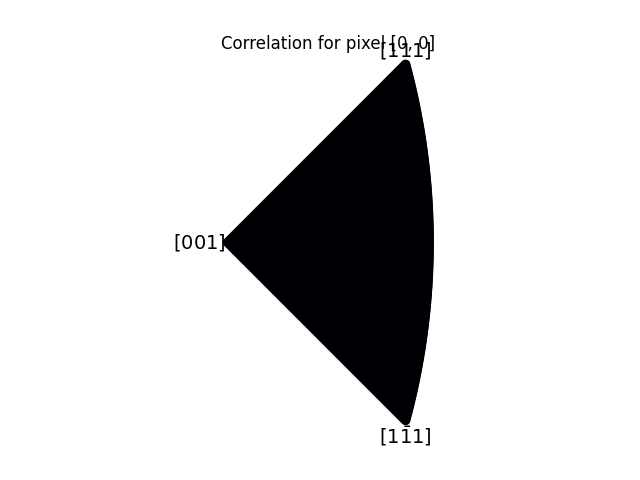

In [33]:
pixel = [0,0]
correlations_i = subset_results.inav[pixel].data[:, 1]
template_indices_i = (subset_results.inav[pixel].data[:,0]).astype('int16')
beam_orientations_i = beam_orientations[template_indices_i]
euler_angles_i = beam_orientations_i.to_euler()

fig = plt.figure()
ax = fig.add_subplot(111, projection="ipf", symmetry=GaAs.point_group)
ax.scatter(beam_orientations_i, c=correlations_i, cmap='inferno')
ax.set_title(f'Correlation for pixel {pixel}')

In [32]:
print(f"Correlation values - Min: {np.nanmin(correlations_i)}, Max: {np.nanmax(correlations_i)}, Mean: {np.nanmean(correlations_i)}")
print(f"Number of NaN values: {np.sum(np.isnan(correlations_i))}")
print(f"Number of points: {len(correlations_i)}")
print(f"Sample values: {correlations_i[:10]}")
print(f"Unique values: {len(np.unique(correlations_i))}")

Correlation values - Min: 0.0, Max: 0.0, Mean: 0.0
Number of NaN values: 0
Number of points: 8281
Sample values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Unique values: 1


We see a clear hot spot at the $[101]$ corner of the IPF, which corresponds well with what our diffraction patterns look like! In addition, the correlation scores of the various beam directions are smoothly varying and showing no signs of noise or other artifacts. It looks like our parameters are sufficient to map the orientation of __this__ diffraction pattern at least. But bear in mind that some patterns in some phases are notoriously hard to match!

We can also output the $h$, $k$, $l$ indices of the reflections in the simulation that was matched to this pixel. Using the `tabulate.tabulate()` function, we can output the results in numerous formats, including html, latex, or markdown!

In [34]:
#fmt = 'html'
#fmt = 'simple'
#fmt = 'latex'
fmt = 'pipe' #For PHP Markdown

# Get the simulation of the template index
beam_direction, phase_index, simulation = simulations.get_simulation(template_indices_i[0]) #Returns a tuple with the beam direction, the phase index, and the simulation
phi1, theta, phi2 = beam_direction.to_euler(degrees=True).flatten() #Get the euler angles of the beam direction follwing the Bunge convention used in Orix.

#Create a nicely formatted table of the hkl indices.
table = tabulate(simulation.hkl, headers=['h', 'k', 'l'], floatfmt='.0f', tablefmt=fmt) 
print(f"(hkl) indices of reflections of euler angles ({phi1:.1f}, {theta:.1f}, {phi2:.1f}) of phase number {phase_index}:\n{table}")

(hkl) indices of reflections of euler angles (0.0, 51.9, 133.0) of phase number 0:
|   h |   k |   l |
|----:|----:|----:|
|   4 |   2 |  -2 |
|   3 |   1 |  -1 |
|   3 |  -1 |  -3 |
|   2 |   4 |   2 |
|   2 |   2 |   0 |
|   2 |  -0 |  -2 |
|   2 |  -2 |  -4 |
|   1 |   3 |   1 |
|   1 |  -1 |  -1 |
|   1 |  -3 |  -3 |
|   0 |   2 |   2 |
|  -0 |  -2 |  -2 |
|  -1 |   3 |   3 |
|  -1 |   1 |   1 |
|  -1 |  -3 |  -1 |
|  -2 |   2 |   4 |
|  -2 |   0 |   2 |
|  -2 |  -2 |  -0 |
|  -2 |  -4 |  -2 |
|  -3 |   1 |   3 |
|  -3 |  -3 |   1 |
|  -4 |  -2 |   2 |


If you need to, you can copy or indeed output this to some file and put in your report or whatever other tools you need. You can also do other interesting things with this, such as determining the zone axis!

In [ ]:
g1 = Miller(hkl=simulation.hkl[0], phase=GaAs)
g2 = Miller(hkl=simulation.hkl[2], phase=GaAs)
P = g1.cross(g2).round()
print(f"Zone axis of template is close to [{P.u[0]:.0f} {P.v[0]:.0f} {P.w[0]:.0f}]")

We see that the calculated zone axis of the best match lies close to the $[101]$ crystal direction - which is exactly what the IPF told us as well! 

# 4. Template match the entire dataset
The next "step" is to template match the entire dataset. We do the same steps as before, but instead of working on a subset, we take the whole dataset. 

First, we azimuthally integrate our signal. This may take some time, and will create a large array of `float64` data. This usually crashes most laptops and computers (with the present data, a total of 28 GiB will be required for the integrated signal __alone__). It is therefore most convenient to work with lazy data, then change the data to `float32` before computing the lazy data and storing it in memory. It will still be a large array, but most laptops can handle it. Of course, computing the data is not strictly necessary, so if you do not need to compute the data you can just leave it as `float64`, but you might run into issues when visualizing and accessing the data.

__NB__ _Parts of the remaining notebook might not work unless you compute the lazy results!_

In [ ]:
npt = int(np.floor(np.sqrt(np.sum((np.array(subset.axes_manager.signal_shape)//2)**2)))) #Number of radial points.
npt_azim = 360 #Number of azimuthal sampling points
signal.change_dtype('float32') #must be float
signal_pol = signal.get_azimuthal_integral2d(npt=npt, npt_azim=npt_azim)
if lazy:
    nav_chunks = (32, 32) # values from notebook
    sig_chuncks = (36, 30) #default values from notebook
    #signal_pol.rechunk(nav_chunks, sig_chunks)
    signal_pol.data = signal_pol.data.rechunk(nav_chunks + sig_chuncks)
    if True: # Set to False if you want to keep the data as float64!
        signal_pol.change_dtype('float32')
    signal_pol.compute()
signal_pol_path = signal_path.with_stem(signal_path.stem + "_pol")
signal.save(signal_pol_path, overwrite=True)

In [ ]:
# a fix to the cell below, 

#signal.compute()

#ensure signal is in float32
#signal.data = np.ascontiguousarray(np.array(signal.data)).astype(np.float32)

## Load the data
If you already have an azimuthally integrated signal stored on disk you can load it here instead of running the above cells.

__NB! It has to have come from the original signal used here for the simulations to be valid! You cannot simply run the first part of this notebook, then load any other signal at this point!__

In [ ]:
signal_pol = hs.load(signal_pol_path)

## Template match
Once the data is azimuthally integrated, we template match it. Let us now only keep the 5 best matches at every point to save some time. `frac_keep` can also be reduced if you want a speedup.

In [ ]:
#n = simulations.current_size #Keep the results from matching all the templates
n = 5 #If you only want to keep the five best results
signal_results = signal_pol.get_orientation(simulation=simulations, n_best=n, frac_keep=1.0)
signal_results

From the table above, we see that the `signal_results` are structured as before, in 4 columns with the template `index`, matching `correlation`, the inplane `rotation` and a `factor` telling us whether the template was mirrored or not. Each of these columns can be accessed with `signal_results.isig[col, n]`, with `n` being the template matching result you are interested in (the best, the second best and so forth). For instance, if you want the correlation score of the best match, you get this by calling `signal_results.isig[1,0]`. If you want the second best, you call `signal_results.isig[1, 1]`, and so on.

## Inspect results

Now we should inspect our results. There are many ways of doing this, and they will depend on your material, type of scan, what you are interested in, etc. However, the idea is usually the same:
1. We want to verify that our results is sensible and physical!
2. We want to verify that the sampling in our simulation is OK!
3. We want to verify that the correlation scores make sense!
4. If we have done any image processing, we want to verify that it was OK and not too intensive or too poor!

This can usually be achieved by plotting
- Our data with markers showing the template matching results
- An IPF
- An IPF map
- A histogram of the correlation scores
- A polefigure

This can be simple enough, or it can be complicated. If you have a tricky structure and/or poor data, you might find that the 2nd, 3rd, 4th, or 5th template match were the best ones rather than the 1st. This would then require you to dive deeper into more complex analysis. This tutorial templatematching notebook is, in that respect, very simplified. 

### Plot in polar space
We start by plotting the azimithally integrated data and overlay the markers from the template matching. This will tell us if the data was suitable matched or not. Things such as incorrect calibration, extensive distrotions (due to camera or material conditions), or image processing issues will be visible. However, since the data is quite big and (possibly) lazily loaded, plotting the data will take a long time. __It might be better to skip the next cell!__

In [ ]:
if True:
    n = signal_results.num_rows
    #n = 1 #If too crowded markers in the plot, uncomment this line to only plot the highest correlation scores
    
    signal_pol.plot(norm='symlog')
    signal_pol.add_marker(
        signal_results.to_single_phase_polar_markers(
            n_best=n,
            signal_axes=signal_pol.axes_manager.signal_axes
        )
    )

We see that if we navigate to the vacuum/protection layer at the top of the scan, the templates match very poorly. However, if we move into the sample, the templates match mutch better! For FCC crystals, the $[101]$ orientation is a very dense orientation, and thus will correlate better to random signals/noise than the other orientations - and the protection layer will be indexed as a $[101]$ direction. Coincidentally, our sample __also__ has a $[101]$ orientation! Determining if a match is good or not is not necessarily straight forward. For now, you can observe that the results up in the top part of the scan are more scattered, while the markers coincide much better inside the sample.

In [ ]:
assert False

## Plot in $k_x,k_y$ space

We can also plot the original signal and show the template that was matched as markers. This is often a more intuite way for us to check the results, and if `annotate=True` is also given, then the        $hkl$ indices will also be displayed. However, there are some cases where the markers __appears__ to be flipped relative to the image. This __might__ not mean that your results are wrong, it __could__ be a known bug in `pyxem`[#1124](https://github.com/pyxem/pyxem/issues/1124), but you should then do some extra checks (your results could of course be wrong as well!).

In [ ]:
signal.plot(cmap='viridis_r', norm='symlog')
signal.add_marker(signal_results.to_markers(annotate=True))

In [ ]:
assert False

Again, if we look at the results from the vacuum/protection layers, the templates only coincide with noise/background signal. If we move into the sample itself, the markers align well with the reflections! This tells us that our template matching is working and that our parameters are __probably__ OK! However, we cannot necessarily be certain of this untill we do some more investigations however. By looking at the $hkl$ annotations we see that the template is close to a $[101]$ zone axis, as we have previously seen!

## Plot some statistics
We can also plot some statistics or deal with the results in many various ways. As an example (albeit not a terribly useful one), let us plot the different correlation scores as histograms. You can do this however you like, but using `pandas` dataframes is a good idea (especially if you want to save these data in other formats than the ones pyxem and orix offer).

An efficient way of doing this is to create a dictionary with the column names as keys and the results as values. The following cell only covers the best score, but you can expand this if you like to also include the other matching results.

In [ ]:
results = pd.DataFrame({signal_results.column_names[i]:signal_results.isig[i,0].data.flatten() for i in range(len(signal_results.column_names))}) #Iterate over the columns and get the column names and the values.
results = results.sort_values('correlation', ascending=False) #Sort the data

#Plot the data
fig, ax = plt.subplots()
sb.histplot(data=results[['correlation']], bins=int(len(results)/10), ax=ax)
ax.set_xlabel('Correlation score')
print(results)

Without going into too much detail, there is a strong peak at low correlation scores, and then a more smooth hump at higher scores. The Strong peak at low correlation scores is due to the vacuum/protection layer part at the top of the scan (we did not remove it before template matching). The smooth hump at higher scores are the parts of the sample that has the crystal structure we have actually simulated.

### Quantitative v.s. qualitative
There can be valuable information in looking at your results like this rather than in a map, and you should always try to extract as much __quantitative__ information from your data and not only __qualitative__ information and nice images. Another interesting piece of information here, is that the correlation scores that corresponds to the vacuum/protection layer (the strong peak) is around $25$% of the correlation score of the actual data, which does not seem insignificant. However, this is a very good example of the ambiguity of the correlation scores. The scores themselves are somewhat arbitrary! Both the "baseline" and the "scale" can change alot from dataset to dataset, so setting a fixed number for what is a good match or not is not doable (in most cases). In this particular case, we could threshold our orientation mapping results at correlation scores at around 1000 to get rid of the uninteresting parts, but for a different scan, we might need to set a different threshold.

# 5. Create a crystal map
When we are satisfied with our results, we can create an `orix` crystal map. This is an object that can be used to plot our results, but also to save them! Let us first save the data to make sure they are not lost. To do this, we will use the `save` function we loaded at the start of this notebook (`from orix.io import save`). Before we do that however, we will extract the correlation scores of the best matching and add that to the `prop` property of the crystal map. The correlation scores of the results are stored in the second column (i.e. index 1), and the best score is the first row (i.e. index 0): `signal_results.isig[1,0]`. Since orix' crystal map work with flattened data arrays, we will also need to flatten the data array before we can store the correlation scores as a property in the crystal map. After adding the properties to the crystal map, we can access them with simple `.`-indexing like `xmap.ci`. This simplifies alot later on!

In [ ]:
xmap = signal_results.to_crystal_map()
xmap.prop['index'] = signal_results.isig[0,0].data.flatten() #Get the template index
xmap.prop['ci'] = signal_results.isig[1,0].data.flatten() #Get the correlation scores of the best scores. Store it as "CI" - Confidence Index. This is a commonly use term for the matching scores in many EBSD solutions
xmap.prop['rotation'] = signal_results.isig[2,0].data.flatten() #Get the inplane rotation
xmap.prop['mirrored'] = signal_results.isig[3,0].data.flatten() #Get the mirrored flag
vbf = signal.get_integrated_intensity(hs.roi.CircleROI(0.0, 0.0, 0.1))
try:
    vbf.compute() #Load the lazy data into memory as you compute the virtual bright field
except Exception as e:
    print(e) #Ignore the error, but print it to let us know something happened.
xmap.prop['vbf'] = vbf.data.flatten() #Get the VBF data and add it as a property
save(datapath.with_stem(f"{datapath.stem}_xmap").with_suffix('.hdf5'), xmap, overwrite=True)
xmap

## Load crystal map
If you have already saved a crystal map, and only want to inspect the results, you can load the data directly.

In [ ]:
xmap=load(datapath.with_stem(f"{datapath.stem}_xmap").with_suffix('.hdf5'))
GaAs = xmap.phases['GaAs']

## Plot IPFs
Next, we can do some quick inspection to check our results. It would be a shame if we went through all this trouble and produced a result that was not useable/correct after all!

One useful way of plotting our data is through IPFs. IPFs show the orientation of a specimen direction ($X$, $Y$, or $Z$) relative to a crystal orientation $[hkl]$. These plots therefore tells you what crystal direction lies along e.g. $X$ (the horizontal of the __detector__) or $Y$ (the vertical of the __detector__). See [orix user guide](https://orix.readthedocs.io/en/stable/tutorials/inverse_pole_figures.html) for more information.

__<span style="color:red">
NB! the $X$, $Y$, and $Z$ directions are NOT defined related to the scan! They are defined related to the DETECTOR horizontals and verticals. Changing the `scan rotation` during the experiment will therefore not change the results and IPFs, unless it is correctly accounted for! Unless the scan and the diffraction patterns are rotated correctly during acquisition, you will most likely need to change the Euler angles in your crystal map to make proper sense of them!</span>__

IPFs come in two "forms". We have already looked at IPFs earlier when checking the orientations we simulated and when we verified some of our results. These are pole figures showing the orientations as dots in a diagram. They do not care about the spatial distribution of the orientations in the scan space. Later on, we will plot an IPF map, that shows the orientation of each point in our scan to get this information as well. While the IPF maps are very tempting to focus on (they are usually colorful and impressive), the IPFs themselves contain a lot of important and useful information (like the polefigures themselves!).

Let us first take a look at the IPFs of the $X$, $Y$, and $Z$ directions

In [ ]:
xmap_filtered = xmap[xmap.ci<100] #treshold from correlation score histogram
oris = xmap_filtered.orientations
corrs = xmap_filtered.ci

oris.scatter('ipf', c=corrs, alpha=corrs/np.max(corrs), direction=Vector3d.xvector(), edgecolors=None, cmap='magma')
oris.scatter('ipf', c=corrs, alpha=corrs/np.max(corrs), direction=Vector3d.yvector(), edgecolors=None, cmap='magma')
oris.scatter('ipf', c=corrs, alpha=corrs/np.max(corrs), direction=Vector3d.zvector(), edgecolors=None, cmap='magma')

From the IPF plots above, we see a few things:

1. There are two clusters in the $z$ IPF. Since this shows the zone axis, we can conclude that there should be at least two different "types" of diffraction patterns. This is important if we are interested in doing e.g. vector matching or neural network analysis: We would only need to account for two orientations and allow any in-plane rotation!
2. The $x$ and $y$ IPFs show five clusters. This means that there are five different orientations in our sample!
3. The clusters in the $x$ and $y$ IPFs all lie along the edges of the IPF. These are often low-index orientations (high symmetry), although you might need to "rotate" the orientations to recognize it (the $x$ and $y$ directions are in principle arbitrarily oriented). It is often most convenient to redefine the specimen coordinate system to some known or recognizeable axes system (e.g. processing directions, growth directions, or grain/phase boundaries).

Since the orientations are neatly clustered, both in the $z$ and the $x$ and $y$ IPFs, we expect that the template matching is good. If the matching did not succeed (due to e.g. wrong calibration or simulation parameters), there would be a lot more scatter and noise. Of course, in some cases you __will__ have nose and scatter because the the material you are looking at has a lot of scatter in the crystal orientations. In such cases, it is definetly important to look at the IPF maps. The IPFs only show the distribution of the various orientations, while the IPF maps show how the orientations are distributed in your scan.

## Plot IPF maps
To plot an IPF map, we must first create a color key that translates an orientation to a color. Think of these color keys as IPFs where each point is assigned a unique color. That way, each orientation can be represented as a color and you can create a map/plot of your scan with those colors. Exactly how to color-code your IPF is a tricky buisiness. You typically want a key that gives you intuitive information in the sense that almost equal orientations shoul have an almost equal color. For some point groups, this can be very tricky and you may come across some creative color keys. A good rule of thumb is to use well-known color keys in the EBSD community to avoid too much confusion. `orix` has support for various color-keys, and the `orix.plot.IPFColorKeyTSL` is often a good choice (see more on [coloring orientations with orix](https://orix.readthedocs.io/en/stable/tutorials/inverse_pole_figures.html#Coloring-orientations)). In the next cell, we plot three IPF maps and the color keys (the color keys are in fact identical, but by creating three separate objects, we can scatterplot our orientations on top of the colors as well if we want to be compact)

In [ ]:
key_x = IPFColorKeyTSL(GaAs.point_group, Vector3d.xvector())
key_y = IPFColorKeyTSL(GaAs.point_group, Vector3d.yvector())
key_z = IPFColorKeyTSL(GaAs.point_group, Vector3d.zvector())

#First plot the key and add the orientations as scatter points
with plt.rc_context({'font.size': 8}): #Temporary set fontsize
    ipf = key_x.plot(return_figure=True)
    xmap.orientations.scatter('ipf', figure=ipf, s=3, color='k', edgecolor='none')
    ipf.set_figheight(3) #Adjust figure height
    ipf.set_figwidth(3) #Adjust figure width

# Calculate the required sizes of the figues
nx, ny = xmap.shape
aspect_ratio = nx/ny
figure_width = 4
figure_kwargs={'figsize': (figure_width, figure_width*aspect_ratio)}

#Plot the IPF maps in individual figures
keys = [key_x, key_y, key_z]
titles = ['$X$', '$Y$', '$Z$']
with plt.rc_context({'font.size': 8}): #Temporary set fontsize
    for key, title in zip(keys, titles):
        figure = xmap.plot(key.orientation2color(xmap.orientations), figure_kwargs=figure_kwargs, remove_padding=True, return_figure=True)
        figure.suptitle(title)

From the IPF maps above we can see:
1. There are a lot of noise in the top part of the scan (seen in the $X$ and $Y$ maps). This can be removed using thresholding (as we did with the IPF figures earlier), or by overlaying the maps with the correlation score value (as we will do later).
2. The Z-map is completely "green" except for a small pink/purple region. The Green color corresponds to the $[101]$ direction, meaning that the $Z$-direction (i.e. beam direction) aligns with the $[101]$ crystal direction. This is also the zone axis we calculated earlier and what we have seen in all the IPF plots so far.
3. There are many different regions in the $X$ and $Y$ maps, with sharp and straight interfaces/boundaries to each other. Each of these regions are different grains with different orientations.
4. In the $Y$ map, there is on small "red" grain. Comparing to the color key, this means that the $Y$-direction aligns with the $[001]$ direction here. The same grain is "green" in the $X$ map, meaning that the $[101]$ direction aligns with $X$ here.

#### A note on indices
Following point in the list above: If $[101]$ aligns with $Z$, the $X$ direction cannot align with $[101]$ as well ($X$ and $Z$ are perpendicular by definition)! The indices in the IPF corners only shows the "family" of directions, not the "unique" directions themselves. We as scientists have to work out the correct signs and combinations of the $hkl$ indices ourselves (it could be coded, but that is not necessarily the best use of our time, especially considering we always have to double check these things ourselves anyways!). We can do this as follows:

1. Decide on the $hkl$ indices of one direction
2. Decide on the $hkl$ indices of the next direction. They have to be perpendicular to the first direction
3. Work out the $hkl$ indices of the final direction given the first two directions.

For the small "red" grain in the $Y$ map above, we know that $X||<101>$, $Y||<100>$, and $Z||<101>$. We need to figure out the correct signs and orders of the $hkl$ indices of these directions that makes them perpendicular (since $X$, $Y$, and $Z$ are perpendicular). 

1. Let us decide $Z||[101]$
2. Let us decide $X||[10\bar{1}]$
3. This makes $Y||[010]$.

Thus, we have determined the orientation of this particular grain. If you now proceed to work out the orientations of the other grains, you should try to keep some of these the same. It is often best to try to keep the zone axis (i.e. $Z$) the same if you can.

### Some more advanced IPF maps
Orix has support for a lot of different plotting options and possibilities. Some of them may seem a bit obscure, but you can usually find the information you need on the [orix examples page](https://orix.readthedocs.io/en/stable/examples/plotting/index.html). In the following, we do the same plotting as we do above, but we change the reference directions, and plot the results in a subplot rather than in separate figures. You can do whatever suits you best.

In [ ]:
direction_1 = Vector3d([1, 0, 1])
direction_2 = Vector3d([1, 1, 1])

keys = [IPFColorKeyTSL(GaAs.point_group, direction) for direction in (direction_1, direction_2, Vector3d.xvector(), Vector3d.yvector(), Vector3d.zvector())]

fig = plt.figure(figsize=(6,1*(len(keys)+1)))

with plt.rc_context({'font.size': 8}):
    for row, key in enumerate(keys):
        ax = fig.add_subplot(len(keys)+1, 1, row+1, projection='plot_map')
        ax.plot_map(xmap['GaAs'], key.orientation2color(xmap.orientations), legend=False)
        ax.axis('off')
        x, y, z = key.direction.x[0], key.direction.y[0], key.direction.z[0]
        if x==y==0 and z==1:
            title = '$Z$'
        elif y==z==0 and x==1:
            title = '$X$'
        elif z==x==0 and y == 1:
            title = '$Y$'
        else:
            title = f"[{key.direction.x[0]}, {key.direction.y[0]}, {key.direction.z[0]}]"
        ax.set_title(title)
        
with plt.rc_context({'font.size': 3}):
    ax_ckey= fig.add_subplot(len(keys)+1, 1, len(keys)+1, projection="ipf", symmetry=GaAs.point_group)
    ax_ckey.plot_ipf_color_key(show_title=False)
    ax_ckey.patch.set_facecolor('None')


plt.tight_layout()

The code and plot above is used to illustrate the "ambiguity" of IPF maps. They are __always__ based on a __reference__ direction! This is extremely important to understand. In the first two plots, we use a reference direction of $[1, 1, 0]=X+Y$ and $[1, \bar{1}, 0]=X-Y$ (not $hkl$ indices). These directions are oriented $45^{\circ}$ relative to $X$ and $Y$ and are still perpendicular to each other. However, now we can see that there are "new" colors to the grains compared to the $X$ and $Y$ maps. There is now two a larger "green" grains in the $X+Y$ map, that appear "red" in the $X-Y$ map. Since our reference directions are rotated $45^{\circ}$ relative to $X$ and $Y$, we can quickly say that these two grains are rotated $45^{\circ}$ around $Z$ relative to the small "red" ("green") grain in the $Y$ ($X$) maps! This is a very powerful conclusion we can draw by simply looking at these IPF maps! If our scan rotation is correct (this cannot be checked after an acquisition and __must__ be checked and verified during the experiment itself), we can start to compare these directions to the interfaces we see. More on this later on.

### Adding an overlay
Adding an overlay to your IPF maps can be very useful as well. For instance, you can overlay the correlation scores of the template matching to show which pixels were good matches, and which were not.

In [ ]:
keys = [IPFColorKeyTSL(GaAs.point_group, direction) for direction in (Vector3d.xvector(), Vector3d.yvector(), Vector3d.zvector())]

# Calculate the required sizes of the figues
nx, ny = xmap.shape
aspect_ratio = nx/ny
figure_width = 4
figure_kwargs={'figsize': (figure_width, figure_width*aspect_ratio)}

for key in keys:
    xmap.plot(key.orientation2color(xmap.orientations), overlay=xmap.ci, figure_kwargs=figure_kwargs, remove_padding=True)

for key in keys:
    xmap.plot(key.orientation2color(xmap.orientations), overlay=xmap.vbf, figure_kwargs=figure_kwargs, remove_padding=True)

With the correlation scores (the first three plots) overlaid, it is much easier to identify the most "trustworthy" parts of the data. The "noisy" protection layer at the top is not visible any more, and the interfaces (where overlap between grains might reduce the correlation scores) are more pronounced. Overlaying the VBF intensities has a similar effect, but the protection layer is still visible and the intensities are less "quantitative" compared to using the correlation scores. Overlaying these data means that we can start to see details even in the $Z$ map (where almost every orientation was identical). There are small defects scattered throughout the crystals, which could be dislocations (dislocations can cause intensity to scatter out from reflections and into the "background" and thus reducing the correlation scores). They could of course (in other materials) be signs of inclusions or other phases that we have incorrectly indexed! You should therefore take time to inspect and verify your patterns and matches in places with low correlation scores.

The "downside" of overlaying correlation scores like this is that the colors in the color key are no longer "valid". It is therefore more difficult to read out exact crystal orientations from the IPF maps, but we are left with a more "general" sense of the crystal directions.

### Thresholding our xmap
We can threshold our crystal map based some parameter as well, if that helps our analysis. It is generally recommended to _not_ do that before saving the data, and rather remove the data from plotting later on - that is a much more general workflow with better transparency. However, we include it as an example in case it is useful (to e.g. remove the protection layer without overlaying the correlation scores):

In [ ]:
xmap_filtered = xmap[xmap.ci>=10]
keys = [IPFColorKeyTSL(GaAs.point_group, direction) for direction in (Vector3d.xvector(), Vector3d.yvector(), Vector3d.zvector())]

# Calculate the required sizes of the figues
nx, ny = xmap_filtered.shape
aspect_ratio = nx/ny
figure_width = 4
figure_kwargs={'figsize': (figure_width, figure_width*aspect_ratio)}

for key in keys:
    xmap_filtered.plot(key.orientation2color(xmap_filtered.orientations), figure_kwargs=figure_kwargs, remove_padding=True)

The colors now appear more vibrant and clear since the correlation scores are no longer overlaid. It is easier to connect any point in the scan to an orientation given the color key, but we also loose some information (the small defects throughout the crystals are gone for instance). It is up to you to decide how to represent the data in the best way and to be as transparent as possible in your work.

## 6. Correcting for the scan rotation

The orientations have so far only been with respect to the __detector__. It is, however, much more useful to consider orientations with respect to the __scan__ as this enables the orientations to be compared to real-space features such as grain boundaries, facets, and so on. If the system has been calibrated correctly, a `scan_rotation`$=0^{\circ}$ aligns the scan axes to the detector axes. Then, if any other `scan_rotation` is used it can be corrected by simply adjusting the Euler angles of the crystal orientations accordingly. If the system has not been calibrated correctly, you are entirely dependendt on some other internal calibration (if you e.g. know the correct crystal orientation of a real-space object such as a twinning boundary, a facet, or an inclusion/precipitate). Without this, you will never be able to correlate crystal orientations to the real space features of your scan!

In the dataset we are working with here, a `scan_rotation` is set in the metadata. We also know that the system was properly calibrated and aligned when we performed the experiment, so we can reasonably trust the `scan_rotation`. The `scan_rotation` of __our__ system is defined as counter clockwise rotation. This is something you can check on the microscope, or by acquiring a scan with and without a scan rotation and recreating VBFs e.t.c. It is strongly advised to acquire non-rotated data as well as rotated for consistency checks!

Let us now correct for the scan rotation and see how it affects the results. To verify that we are rotating about the correct axis etc, we will plot IPFs with large blue dots for the non rotated scan and smaller red dots for the rotated scan. We expect a mess in the $X$ and $Y$ directions, but the IPF of the $Z$ direction should be unchanged (the red dots should align with the blue dots). We also plot the IPF maps at the end.

In [ ]:
from orix.crystal_map import CrystalMap

print(f'Scan rotation is {signal.metadata.Acquisition_instrument.TEM.scan_rotation} degrees counter clockwise. Correcting orientations...')

#Get the orientations as euler angles and rotate them
xmap_euler = xmap.orientations.to_euler(degrees=True)
xmap_euler[:, 0] += signal.metadata.Acquisition_instrument.TEM.scan_rotation#Add the scan rotation to the first euler angle of the orientations. This rotates the orientations counter clockwise.
rotations_corr = Rotation.from_euler(xmap_euler, degrees=True)

#Recreate the crystal map
xmap_corr = CrystalMap(
    rotations=rotations_corr,
    phase_id=xmap.phase_id,
    x=xmap.x,
    y=xmap.y,
    phase_list=xmap.phases,
    prop=xmap.prop
)
xmap_corr.scan_unit = xmap.scan_unit

#Plot some IPFs to be sure the rotation was correct
directions = [Vector3d.xvector(), Vector3d.yvector(), Vector3d.zvector()]
for direction in directions:
    fig = xmap_corr.orientations.scatter('ipf', c='b', s=10, direction=direction, return_figure=True, edgecolor='none')
    xmap.orientations.scatter('ipf', figure=fig, c='r', s=5, direction=direction, edgecolor='none')
    fig.set_figheight(3)
    fig.set_figwidth(3)

#Plot some IPF maps to visualize the results
keys = [IPFColorKeyTSL(GaAs.point_group, direction) for direction in directions]
# Calculate the required sizes of the figues
nx, ny = xmap_corr.shape
aspect_ratio = nx/ny
figure_width = 4
figure_kwargs={'figsize': (figure_width, figure_width*aspect_ratio)}

for key in keys:
    xmap_corr.plot(key.orientation2color(xmap_corr.orientations), figure_kwargs=figure_kwargs, remove_padding=True)
    
    overlay=xmap_corr.ci

We do indeed see that the IPFs of the $X$ and $Y$ directions change, but that the $Z$ IPF is unchanged. The same goes for the IPF maps. This verifies that the axis we are rotating our data about is correct. However, it says nothing about the correctness of the `scan_rotation` value! To verify this, we will need to plot our diffraction patterns as well, and compare with the IPFs. The easiest thing to do is to plot our data, navigate to a point in the scan that is (preferably) red/green in the $X$ or $Y$ directions and rotate that pattern with the same angle.

Running the next cell selects the pattern at (368, 22) which corresponds to a "red" $X$ orientation, meaning that $X$ aligns with $[100]$. The same point is a "green" $Y$ orientation, so $Y$ should align with $[101]$. Thus, we expect that the rotated diffraction pattern has a $(202)$ reflection directly "up" from $(000)$, and a $(101)$ reflection directly to the "right" of the $(000)$.

In [ ]:
signal.axes_manager.indices=(38, 22) #Position where the $X$ direction is "red" in the corrected IPF map
signal.plot(norm='symlog')
img = signal.inav[signal.axes_manager.indices].deepcopy()
rotated_img = img.rotate_diffraction(angle=-signal.metadata.Acquisition_instrument.TEM.scan_rotation) #Counterclockwise rotation
rotated_img.plot(norm='symlog')

We do indeed see that the rotated pattern has the expected orientation, and we can trust that the scan rotation we applied is correct! Let us save the corrected crystal map as well!

In [ ]:
save(datapath.with_stem(f"{datapath.stem}_xmap_corr").with_suffix('.hdf5'), xmap_corr, overwrite=True)